# Project FORESIGHT — M2: Weekly Panel & Baseline Forecast

**Client:** NorthBay Living
**Project:** Demand & Inventory Intelligence
**Milestone:** M2 — EDA & Baseline (supports D2 insight memo, satisfies D3 baseline requirement)

This notebook picks up from D1's processed outputs (`sales_daily`, `sku_master`) and:

1. Defines the SKU scope to forecast (D1 delivered 4,916 SKUs — most have too little history or are discontinued to forecast meaningfully).
2. Builds a dense, zero-filled weekly demand panel — the shape every downstream model needs.
3. Implements WAPE, the engagement's accuracy metric (Appendix B).
4. Implements the seasonal-naive baseline the brief requires as "the bar every model must beat" (Appendix B), and backtests it with rolling-origin CV — never a random split, per the engagement's non-negotiable rule (§7.1).
5. Reports an honest comparison against simpler naive alternatives, because the backtest surfaces a real finding worth flagging before Week 3 modelling starts.
6. Exports the panel, the SKU scope, and the backtest results for the Day 11–14 model work.

**Inputs:** `../data/foresight_data/processed/sales_daily.csv`, `sku_master.csv` (from D1)
**Outputs:** `../data/foresight_data/processed/weekly_panel.csv`, `core_sku_scope.csv`, `baseline_backtest_results.csv`, `baseline_comparison.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
%matplotlib inline

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load D1 Outputs

In [2]:
sales_daily = pd.read_csv("../data/foresight_data/processed/sales_daily.csv", parse_dates=["date"])
sku_master = pd.read_csv(
    "../data/foresight_data/processed/sku_master.csv",
    parse_dates=["first_sale_date", "last_sale_date"],
)

MIN_DATE = sales_daily["date"].min()
MAX_DATE = sales_daily["date"].max()

print("sales_daily:", sales_daily.shape)
print("sku_master:", sku_master.shape)
print("Date range:", MIN_DATE.date(), "to", MAX_DATE.date())
display(sales_daily.head())

sales_daily: (532838, 5)
sku_master: (4916, 7)
Date range: 2009-12-01 to 2011-12-09


,date,sku_id,units_sold,revenue,unit_price
0,2009-12-01,10002,12.0,10.2,0.850
1,2009-12-01,10120,60.0,12.6,0.210
2,2009-12-01,10123C,3.0,3.9,1.300
3,2009-12-01,10123G,2.0,3.4,1.700
4,2009-12-01,10125,5.0,5.1,1.275


## 2. Define the Forecasting Scope

D1 delivered 4,916 SKUs. Forecasting all of them isn't meaningful — 13% have fewer than 8 distinct sale-days
in two years, and many are one-off or discontinued items. Rather than silently dropping them, we apply two
explicit, documented filters and report exactly what each one excludes. Everything excluded here still gets
covered in the D2 EDA memo as "long-tail / insufficient-history" and, per the brief's own risk mitigation
(§16.2), falls back to category-level patterns rather than being forecast individually.

**Filters (both must pass):**
- **Recency** — at least one sale within the last `RECENT_WINDOW_WEEKS` weeks of the dataset (still an active SKU, not discontinued).
- **History** — at least `MIN_HISTORY_WEEKS` weeks between first and last sale (enough history to support a 52-week seasonal lookback in the backtest).

Both thresholds are named constants — change them here if you want a tighter or looser scope; nothing downstream is hardcoded.

In [3]:
RECENT_WINDOW_WEEKS = 8   # must have sold within the last 8 weeks of the dataset to be "active"
MIN_HISTORY_WEEKS = 52    # must have >= 1 year of history to support seasonal-naive backtesting

recent_cutoff = MAX_DATE - pd.Timedelta(weeks=RECENT_WINDOW_WEEKS)

sku_master["history_weeks"] = (sku_master["last_sale_date"] - sku_master["first_sale_date"]).dt.days / 7
sku_master["is_recent"] = sku_master["last_sale_date"] >= recent_cutoff
sku_master["is_long_enough"] = sku_master["history_weeks"] >= MIN_HISTORY_WEEKS
sku_master["in_core_scope"] = sku_master["is_recent"] & sku_master["is_long_enough"]

core_skus = sku_master.loc[sku_master["in_core_scope"], "sku_id"]
total_revenue = sku_master["total_revenue"].sum()
core_revenue = sku_master.loc[sku_master["in_core_scope"], "total_revenue"].sum()

scope_summary = pd.DataFrame({
    "metric": [
        "Total SKUs (D1)",
        f"Pass recency filter (sold within {RECENT_WINDOW_WEEKS}w of {MAX_DATE.date()})",
        f"Pass history filter (>= {MIN_HISTORY_WEEKS}w span)",
        "Pass BOTH — core forecasting scope",
        "Core scope revenue share",
    ],
    "value": [
        len(sku_master),
        int(sku_master["is_recent"].sum()),
        int(sku_master["is_long_enough"].sum()),
        int(sku_master["in_core_scope"].sum()),
        f"{core_revenue / total_revenue:.1%}",
    ],
})
display(scope_summary)

,metric,value
0,Total SKUs (D1),4916
1,Pass recency filter (sold within 8w of 2011-12...,3126
2,Pass history filter (>= 52w span),3172
3,Pass BOTH — core forecasting scope,2475
4,Core scope revenue share,79.0%


## 3. Build the Dense Weekly Demand Panel

`sales_daily` is sparse by construction — it only has a row where a SKU actually sold that day, and the
business is closed on weekends and public holidays anyway (135 of 738 calendar days in D1 have zero sales
*across every SKU*). For weekly forecasting we need a **dense** grid: every core SKU × every week in range,
with true zero-sale weeks filled as 0 rather than missing. Missing and zero mean different things — this
step makes sure that distinction never leaks into the model as a bug.

In [4]:
scoped = sales_daily[sales_daily["sku_id"].isin(core_skus)].copy()

# Aggregate to weekly (week starting Monday)
weekly_sparse = (
    scoped.set_index("date")
    .groupby("sku_id")["units_sold"]
    .resample("W-MON", label="left", closed="left")
    .sum()
    .reset_index()
)

full_weeks = pd.date_range(weekly_sparse["date"].min(), weekly_sparse["date"].max(), freq="W-MON")

# Dense reindex: every core SKU x every week
panel_index = pd.MultiIndex.from_product([core_skus, full_weeks], names=["sku_id", "date"])
panel = (
    weekly_sparse.set_index(["sku_id", "date"])["units_sold"]
    .reindex(panel_index, fill_value=0)
    .reset_index()
)

print("Core SKUs:", len(core_skus))
print("Weeks in range:", len(full_weeks), f"({full_weeks.min().date()} to {full_weeks.max().date()})")
print("Weekly panel shape:", panel.shape, "(expected:", len(core_skus) * len(full_weeks), ")")

# Validation
assert panel.shape[0] == len(core_skus) * len(full_weeks)
assert panel["units_sold"].isna().sum() == 0
assert (panel["units_sold"] >= 0).all()
assert panel.duplicated(["sku_id", "date"]).sum() == 0
print("Panel validation PASSED.")

display(panel.head())

Core SKUs: 2475
Weeks in range: 106 (2009-11-30 to 2011-12-05)
Weekly panel shape: (262350, 3) (expected: 262350 )
Panel validation PASSED.


,sku_id,date,units_sold
0,10080,2009-11-30,4.0
1,10080,2009-12-07,0.0
2,10080,2009-12-14,0.0
3,10080,2009-12-21,0.0
4,10080,2009-12-28,0.0


## 4. WAPE — the Accuracy Metric

Per Appendix B: **WAPE** (Weighted Absolute Percentage Error) — total absolute error divided by total actual
demand. It's the primary metric because it stays well-behaved for the low-volume SKUs where MAPE explodes
(division by a near-zero actual). **Bias** (signed mean error) is tracked alongside it as the secondary
check the brief calls for — it tells us whether the baseline systematically over- or under-forecasts, which
WAPE alone can't reveal (a model can have low WAPE while being consistently biased in one direction).

In [5]:
def wape(actual, forecast):
    """Weighted Absolute Percentage Error. Lower is better; 0 = perfect, 1.0 = error as large as total demand."""
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    denom = np.abs(actual).sum()
    if denom == 0:
        return np.nan
    return np.abs(actual - forecast).sum() / denom


def bias(actual, forecast):
    """Signed mean error. Positive = under-forecasting on average; negative = over-forecasting."""
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    return float(np.mean(actual - forecast))


print("WAPE and bias defined.")

WAPE and bias defined.


## 5. Baseline Definition — Seasonal-Naive

Per Appendix B, the required baseline predicts **demand equal to the same period last season** — here, the
same ISO week 52 weeks earlier. Where a SKU doesn't have a valid 52-week-back observation (shouldn't happen
inside our core scope given the history filter, but the function is defensive), it falls back to that SKU's
trailing 4-week mean rather than silently returning zero.

In [6]:
SEASONAL_LAG_WEEKS = 52

def seasonal_naive_forecast(panel_df, origin_date, horizon_weeks, seasonal_lag=SEASONAL_LAG_WEEKS):
    """
    Forecast `horizon_weeks` weeks starting at `origin_date` for every SKU in panel_df.
    Primary rule : value from `seasonal_lag` weeks before the target week (same week last year).
    Fallback     : that SKU's trailing 4-week mean as of origin_date, used only if the seasonal lookup
                   falls outside the panel's date range.
    """
    target_weeks = pd.date_range(origin_date, periods=horizon_weeks, freq="W-MON")
    lookup = panel_df.set_index(["sku_id", "date"])["units_sold"]

    trailing_start = origin_date - pd.Timedelta(weeks=4)
    trailing_mean = (
        panel_df[(panel_df["date"] >= trailing_start) & (panel_df["date"] < origin_date)]
        .groupby("sku_id")["units_sold"].mean()
    )

    rows = []
    for sku in panel_df["sku_id"].unique():
        fallback_val = trailing_mean.get(sku, 0.0)
        for tw in target_weeks:
            seasonal_date = tw - pd.Timedelta(weeks=seasonal_lag)
            try:
                val = lookup.loc[(sku, seasonal_date)]
                used_fallback = False
            except KeyError:
                val = fallback_val
                used_fallback = True
            rows.append((sku, tw, val, used_fallback))

    return pd.DataFrame(rows, columns=["sku_id", "date", "forecast", "used_fallback"])

print("seasonal_naive_forecast defined.")

seasonal_naive_forecast defined.


## 6. Rolling-Origin Backtest

Never a single random split for time series (§7.1's non-negotiable rule) — a random split lets future weeks
leak into "training" via the seasonal lookup. Instead we pick several **origins** near the end of the panel,
each time forecasting forward `HORIZON_WEEKS` and only ever looking backward from that origin. This mimics
how NorthBay will actually use the model: standing at today, forecasting forward.

In [7]:
HORIZON_WEEKS = 6        # forecast horizon — mid-point of the brief's 6-8 week guidance (§03)
N_ORIGINS = 4             # number of backtest origins
ORIGIN_STEP_WEEKS = 4     # spacing between origins

last_possible_origin = full_weeks.max() - pd.Timedelta(weeks=HORIZON_WEEKS - 1)
origins = sorted(last_possible_origin - pd.Timedelta(weeks=ORIGIN_STEP_WEEKS * i) for i in range(N_ORIGINS))

panel_lookup = panel.set_index(["sku_id", "date"])["units_sold"]

backtest_rows = []
for origin in origins:
    fc = seasonal_naive_forecast(panel, origin, HORIZON_WEEKS).set_index(["sku_id", "date"])
    actual = panel_lookup.reindex(fc.index)
    backtest_rows.append({
        "origin": origin.date(),
        "wape": wape(actual.values, fc["forecast"].values),
        "bias": bias(actual.values, fc["forecast"].values),
        "fallback_rate": fc["used_fallback"].mean(),
        "n_sku_weeks": len(fc),
    })

backtest_results = pd.DataFrame(backtest_rows)
display(backtest_results)

print(f"\nSeasonal-naive baseline — mean WAPE across {N_ORIGINS} origins: {backtest_results['wape'].mean():.4f}")
print(f"Seasonal-naive baseline — mean bias across {N_ORIGINS} origins: {backtest_results['bias'].mean():+.2f} units/week")

,origin,wape,bias,fallback_rate,n_sku_weeks
0,2011-08-08,1.190369,-5.667273,0.0,14850
1,2011-09-05,1.192938,-12.806599,0.0,14850
2,2011-10-03,1.096903,-12.545253,0.0,14850
3,2011-10-31,0.984528,-10.435892,0.0,14850



Seasonal-naive baseline — mean WAPE across 4 origins: 1.1162
Seasonal-naive baseline — mean bias across 4 origins: -10.36 units/week


## 7. Naive Baseline Comparison — an Honest Finding

The seasonal-naive result above is **the required D3 baseline** — it's what the Week 3 model has to beat,
and it's reported as-is. But it's worth checking it against simpler alternatives before assuming it's the
right bar, the same way the brief asks us to check the *model* against the baseline rather than trust a
good-looking number blind.

Below: seasonal-naive against a plain last-week persistence forecast and trailing-mean forecasts (4 and 8
week windows), all backtested on the same origins.

In [8]:
def trailing_mean_forecast(panel_df, origin_date, horizon_weeks, window):
    target_weeks = pd.date_range(origin_date, periods=horizon_weeks, freq="W-MON")
    start = origin_date - pd.Timedelta(weeks=window)
    tmean = (
        panel_df[(panel_df["date"] >= start) & (panel_df["date"] < origin_date)]
        .groupby("sku_id")["units_sold"].mean()
    )
    rows = [(sku, tw, tmean.get(sku, 0.0))
            for sku in panel_df["sku_id"].unique() for tw in target_weeks]
    return pd.DataFrame(rows, columns=["sku_id", "date", "forecast"]).set_index(["sku_id", "date"])


def persistence_forecast(panel_df, origin_date, horizon_weeks):
    target_weeks = pd.date_range(origin_date, periods=horizon_weeks, freq="W-MON")
    last_val = panel_df[panel_df["date"] == origin_date - pd.Timedelta(weeks=1)].set_index("sku_id")["units_sold"]
    rows = [(sku, tw, last_val.get(sku, 0.0))
            for sku in panel_df["sku_id"].unique() for tw in target_weeks]
    return pd.DataFrame(rows, columns=["sku_id", "date", "forecast"]).set_index(["sku_id", "date"])


candidate_methods = {
    "seasonal_naive (required baseline)": lambda o: seasonal_naive_forecast(panel, o, HORIZON_WEEKS).set_index(["sku_id", "date"])[["forecast"]],
    "persistence_last_week": lambda o: persistence_forecast(panel, o, HORIZON_WEEKS),
    "trailing_4wk_mean": lambda o: trailing_mean_forecast(panel, o, HORIZON_WEEKS, window=4),
    "trailing_8wk_mean": lambda o: trailing_mean_forecast(panel, o, HORIZON_WEEKS, window=8),
}

comparison_rows = []
for name, fn in candidate_methods.items():
    wapes = []
    for origin in origins:
        fc = fn(origin)
        actual = panel_lookup.reindex(fc.index)
        wapes.append(wape(actual.values, fc["forecast"].values))
    comparison_rows.append({"method": name, "mean_wape": np.mean(wapes)})

baseline_comparison = pd.DataFrame(comparison_rows).sort_values("mean_wape").reset_index(drop=True)
display(baseline_comparison)

,method,mean_wape
0,trailing_8wk_mean,0.711751
1,trailing_4wk_mean,0.733147
2,persistence_last_week,0.839971
3,seasonal_naive (required baseline),1.116185


**Finding:** trailing-mean forecasts noticeably outperform the literal seasonal-naive at this SKU-week grain
— with only one full prior year on record, "same week 52 weeks ago" is a single noisy data point per SKU,
while a trailing average smooths that noise out. This is expected, not a bug, and it's worth stating plainly
in the D2 EDA memo: **annual seasonality is real at the category/aggregate level (see the Christmas peak in
top movers) but weak and noisy as a per-SKU weekly signal with only ~2 years of history.**

Two consequences for Week 3:
- The **required baseline to beat stays seasonal-naive**, per the brief's own definition — that number is reported above and is what D3's model gets backtested against.
- When engineering features for the actual model (Day 9), **prioritise rolling/trailing-window features (4-week, 8-week mean, rolling std) over an exact 52-week-lag feature** — this backtest is direct evidence they'll carry more signal than a raw yearly lag at this grain.

## 8. Visual Sanity Check

One fast-moving and one slower core SKU, actual vs. seasonal-naive forecast over the most recent backtest
origin's horizon — the same illustrative shape as Figure 5 in the brief.

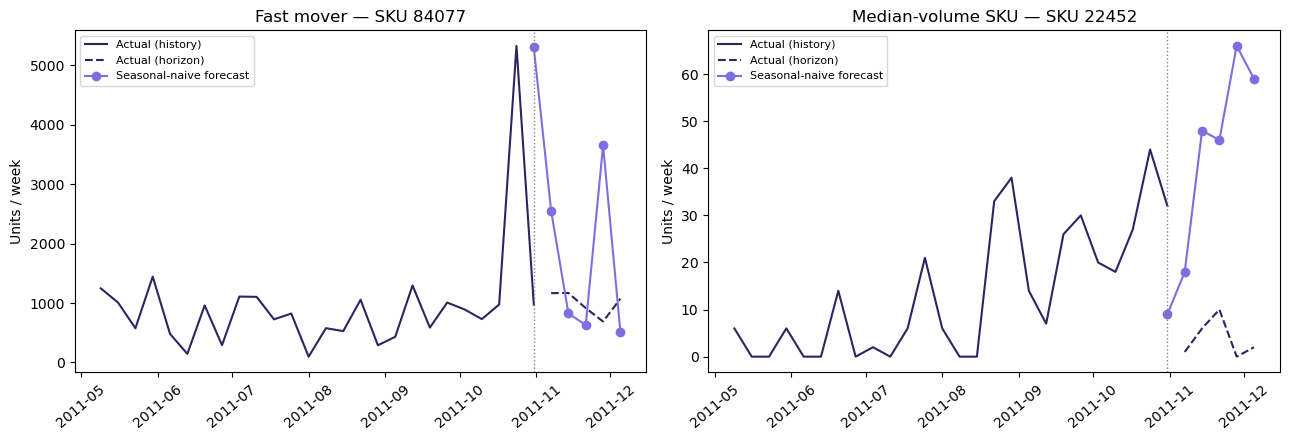

In [9]:
example_skus = (
    sku_master[sku_master["in_core_scope"]]
    .sort_values("total_units_sold", ascending=False)
)
fast_mover = example_skus.iloc[0]["sku_id"]
slow_mover = example_skus.iloc[len(example_skus) // 2]["sku_id"]  # median core SKU by volume

last_origin = origins[-1]
fc_last = seasonal_naive_forecast(panel, last_origin, HORIZON_WEEKS)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, sku, label in zip(axes, [fast_mover, slow_mover], ["Fast mover", "Median-volume SKU"]):
    hist = panel[(panel["sku_id"] == sku) & (panel["date"] <= last_origin)].tail(26)
    fut_actual = panel[(panel["sku_id"] == sku) & (panel["date"] > last_origin) &
                        (panel["date"] <= last_origin + pd.Timedelta(weeks=HORIZON_WEEKS))]
    fut_forecast = fc_last[fc_last["sku_id"] == sku]

    ax.plot(hist["date"], hist["units_sold"], color="#2b2560", label="Actual (history)")
    ax.plot(fut_actual["date"], fut_actual["units_sold"], color="#2b2560", linestyle="--", label="Actual (horizon)")
    ax.plot(fut_forecast["date"], fut_forecast["forecast"], color="#7c6fe0", marker="o", label="Seasonal-naive forecast")
    ax.axvline(last_origin, color="grey", linestyle=":", linewidth=1)
    ax.set_title(f"{label} — SKU {sku}")
    ax.set_ylabel("Units / week")
    ax.tick_params(axis="x", rotation=40)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. Export for Week 3

Everything the Day 11–14 modelling step needs: the SKU scope (with inclusion/exclusion reasons), the dense
weekly panel, and both backtest tables so the model's WAPE has a documented number to beat.

In [10]:
os.makedirs("../data/foresight_data/processed", exist_ok=True)
os.makedirs("../data/foresight_reports", exist_ok=True)

sku_master.to_csv("../data/foresight_data/processed/core_sku_scope.csv", index=False)
panel.to_csv("../data/foresight_data/processed/weekly_panel.csv", index=False)
backtest_results.to_csv("../data/foresight_reports/baseline_backtest_results.csv", index=False)
baseline_comparison.to_csv("../data/foresight_reports/baseline_comparison.csv", index=False)

print("Exported:")
print(" - core_sku_scope.csv       ", sku_master.shape)
print(" - weekly_panel.csv         ", panel.shape)
print(" - baseline_backtest_results.csv", backtest_results.shape)
print(" - baseline_comparison.csv  ", baseline_comparison.shape)

Exported:
 - core_sku_scope.csv        (4916, 11)
 - weekly_panel.csv          (262350, 3)
 - baseline_backtest_results.csv (4, 5)
 - baseline_comparison.csv   (4, 2)


## Summary — M2 Handoff

- **Forecasting scope:** core SKUs only (active + >= 1 year history) — see §2 for the exact count and revenue coverage; everything excluded is documented, not silently dropped.
- **Weekly panel:** dense, zero-filled, validated — no missing-vs-zero ambiguity going into Week 3.
- **Required baseline (seasonal-naive):** backtested with rolling-origin CV across multiple origins — this is the number the Week 3 model must beat, and by how much.
- **Honest finding:** trailing-mean naive forecasts currently beat literal seasonal-naive at this grain — flagged for the D2 memo and for feature-engineering priorities, not swapped in as the baseline (the brief's spec still gets built and reported as-is).
- **Next:** Day 9 feature engineering (lags, rolling stats, calendar/promo signals) → Day 11–14 model training and evaluation against the seasonal-naive number captured here.